In [1]:
import pandas as pd

df = pd.read_csv("../data/reservoirs.csv")
print(df.shape)
print(df.dtypes)
df.head()

(14877, 11)
dato_Id                         str
omrType                         str
omrnr                         int64
iso_aar                       int64
iso_uke                       int64
fyllingsgrad                float64
kapasitet_TWh               float64
fylling_TWh                 float64
neste_Publiseringsdato          str
fyllingsgrad_forrige_uke    float64
endring_fyllingsgrad        float64
dtype: object


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [2]:
# Inspect the categorical dimensions before deciding how to reshape the data.
for col in ["omrType", "omrnr"]:
    print(col, sorted(df[col].unique()))

print("\nRows per area type:")
print(df.groupby(["omrType", "omrnr"]).size())

print("\nYear range:", df["iso_aar"].min(), "-", df["iso_aar"].max())

omrType ['EL', 'NO', 'VASS']
omrnr [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rows per area type:
omrType  omrnr
EL       1        1653
         2        1653
         3        1653
         4        1653
         5        1653
NO       0        1653
VASS     1        1653
         2        1653
         3        1653
dtype: int64

Year range: 1995 - 2026


In [3]:
# The dataset is in long format with one row per (area, week).
# EL 1-5 are price areas, VASS 1-3 are watercourse areas, NO 0 is the national total.
# Part 1 uses the national total so that each column becomes a single time series.
national = df[(df["omrType"] == "NO") & (df["omrnr"] == 0)].copy()

# dato_Id is the ISO date of the measurement week. Parse it and use it as the index.
national["dato_Id"] = pd.to_datetime(national["dato_Id"])
national = national.sort_values("dato_Id").set_index("dato_Id")

# Norwegian source headers -> English. Kept explicit so the mapping is auditable.
COLUMN_NAMES_EN = {
    "fyllingsgrad": "Fill level (fraction)",
    "kapasitet_TWh": "Capacity (TWh)",
    "fylling_TWh": "Stored energy (TWh)",
    "fyllingsgrad_forrige_uke": "Fill level previous week (fraction)",
    "endring_fyllingsgrad": "Change in fill level (fraction)",
}

# Drop the bookkeeping columns: area identifiers are now constant,
# iso_aar/iso_uke are redundant with the datetime index, and
# neste_Publiseringsdato is a publication timestamp with placeholder values.
reservoirs = national[list(COLUMN_NAMES_EN)].rename(columns=COLUMN_NAMES_EN)

print(reservoirs.shape)
print(reservoirs.index.min(), "to", reservoirs.index.max())
reservoirs.head()

(1653, 5)
1995-01-08 00:00:00 to 2026-09-06 00:00:00


,Fill level (fraction),Capacity (TWh),Stored energy (TWh),Fill level previous week (fraction),Change in fill level (fraction)
dato_Id,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


Matplotlib is building the font cache; this may take a moment.


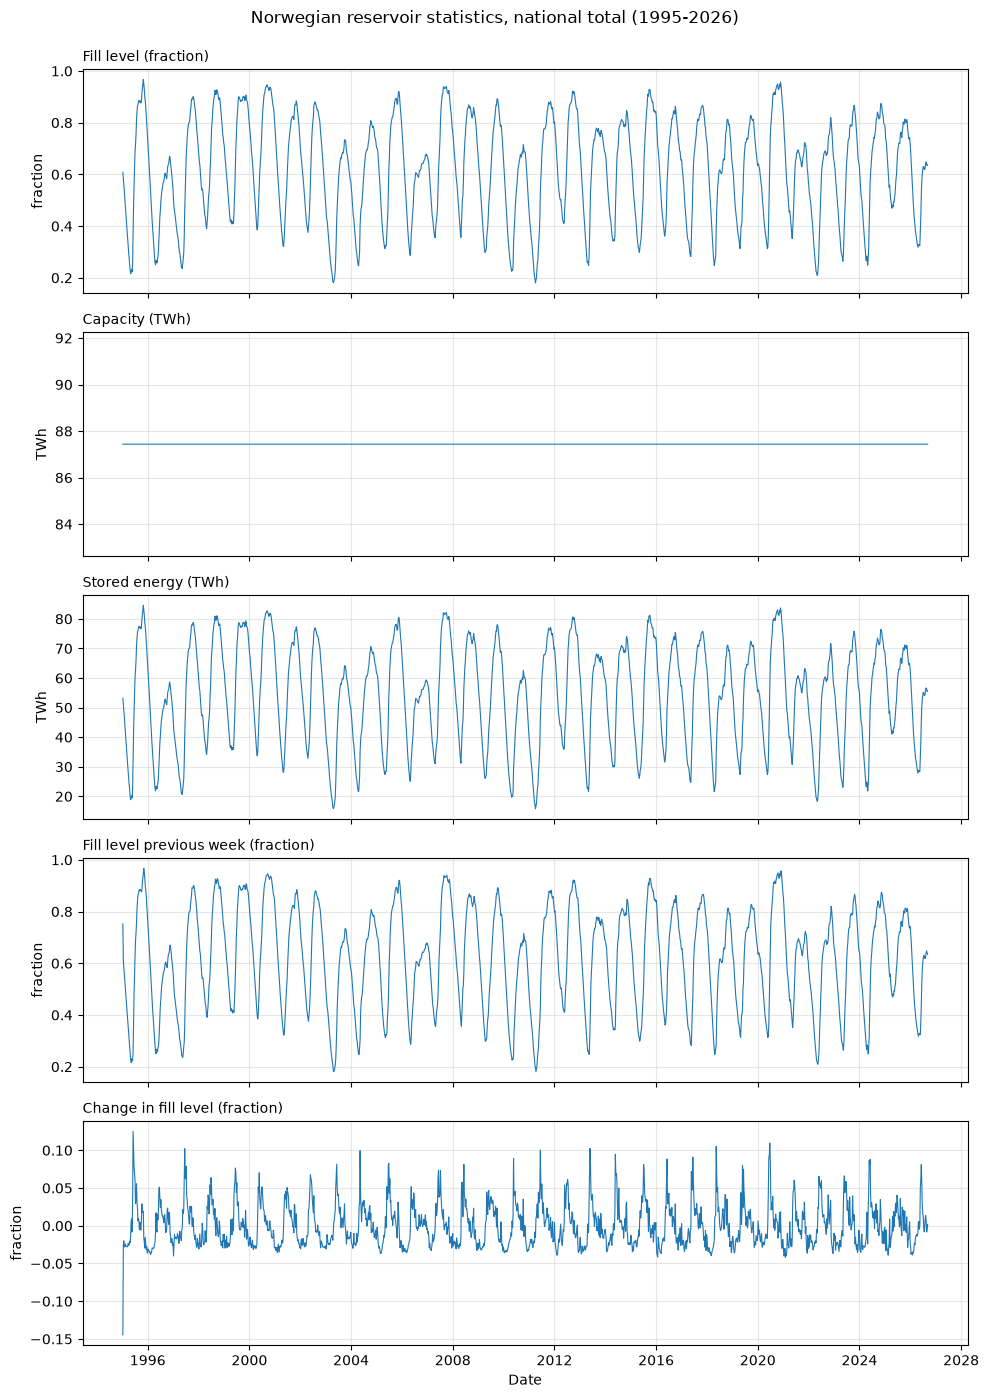

In [4]:
import matplotlib.pyplot as plt

# One subplot per column. Separate axes because the columns use different units.
fig, axes = plt.subplots(len(reservoirs.columns), 1, figsize=(10, 14), sharex=True)

for ax, col in zip(axes, reservoirs.columns):
    ax.plot(reservoirs.index, reservoirs[col], linewidth=0.8)
    ax.set_title(col, fontsize=10, loc="left")
    ax.set_ylabel(col.split("(")[-1].rstrip(")"))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Norwegian reservoir statistics, national total (1995-2026)", y=0.995)
fig.tight_layout()
plt.show()

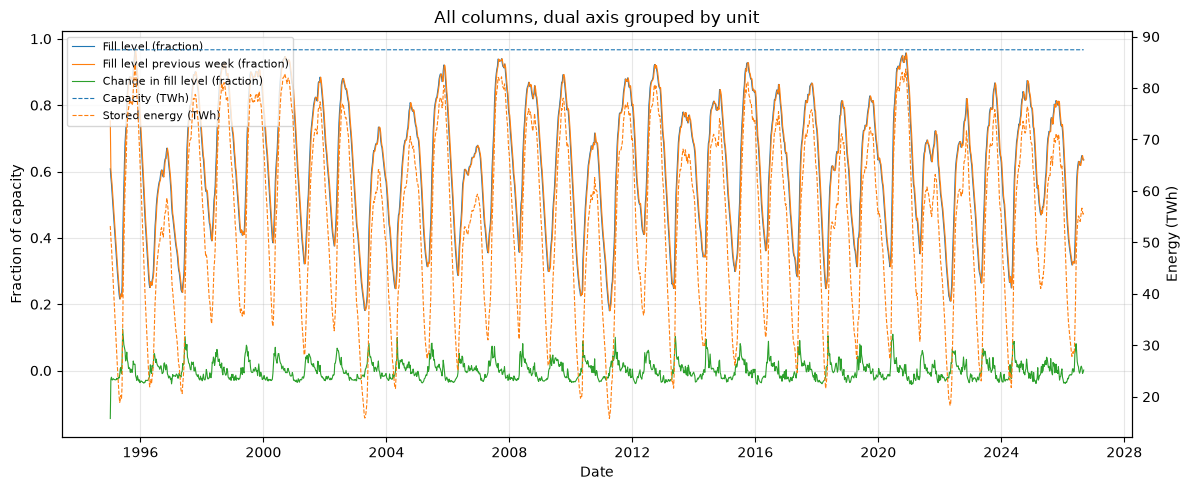

In [5]:
# Approach 1: group columns by unit and use a secondary y-axis.
# Fractions (0-1) on the left, TWh (0-90) on the right.
fraction_cols = [c for c in reservoirs.columns if "fraction" in c]
twh_cols = [c for c in reservoirs.columns if "TWh" in c]

fig, ax_left = plt.subplots(figsize=(12, 5))
ax_right = ax_left.twinx()

for col in fraction_cols:
    ax_left.plot(reservoirs.index, reservoirs[col], linewidth=0.8, label=col)
for col in twh_cols:
    ax_right.plot(reservoirs.index, reservoirs[col], linewidth=0.8,
                  linestyle="--", label=col)

ax_left.set_xlabel("Date")
ax_left.set_ylabel("Fraction of capacity")
ax_right.set_ylabel("Energy (TWh)")
ax_left.grid(alpha=0.3)

# Merge the legends from both axes into one box.
handles = ax_left.get_legend_handles_labels()[0] + ax_right.get_legend_handles_labels()[0]
labels = ax_left.get_legend_handles_labels()[1] + ax_right.get_legend_handles_labels()[1]
ax_left.legend(handles, labels, fontsize=8, loc="upper left")

ax_left.set_title("All columns, dual axis grouped by unit")
fig.tight_layout()
plt.show()

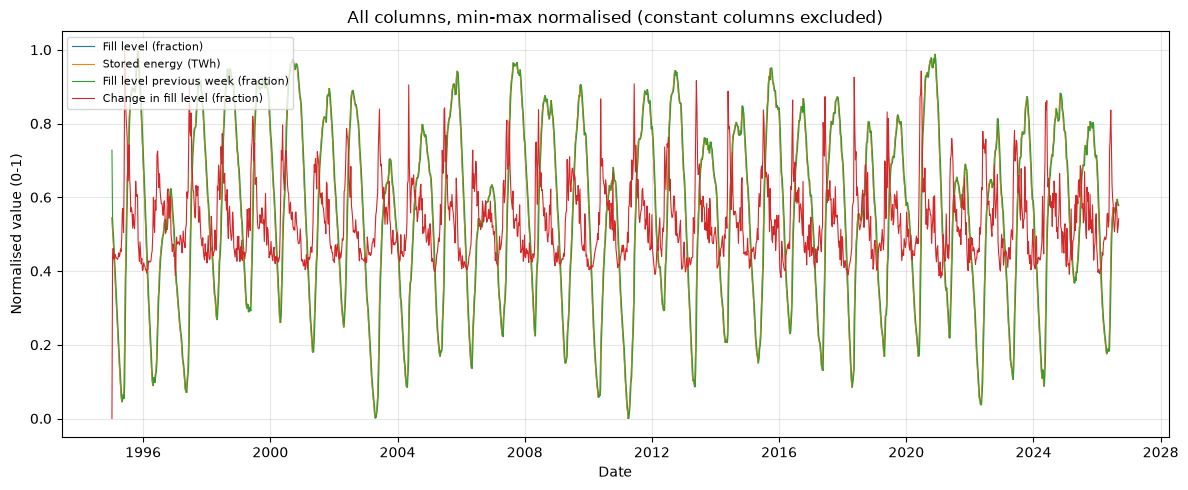

In [7]:
# Min-max normalisation divides by (max - min), which is zero for a constant
# column. Capacity is constant for the national total, so it is excluded here
# rather than producing NaN.
value_range = reservoirs.max() - reservoirs.min()
varying = reservoirs.loc[:, value_range > 0]

normalised = (varying - varying.min()) / (varying.max() - varying.min())

fig, ax = plt.subplots(figsize=(12, 5))
for col in normalised.columns:
    ax.plot(normalised.index, normalised[col], linewidth=0.8, label=col)

ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0-1)")
ax.set_title("All columns, min-max normalised (constant columns excluded)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()